## Descriptive Statistics

In [ ]:
import math
import statistics as stats

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


### Mean
<image src= "../images/mean.png" width= "300">

In [38]:
values = np.array([10, 20, 10, 40, 30])
print(f"Mean: {np.mean(values)}")


Mean: 22.0


### Median

In [39]:
values = np.array([10, 20, 10, 40, 30])
print(f"Median: {np.median(values)}")


Median: 20.0


In [40]:
values = np.array([1, 2, 3, 4])
print(f"Median: {np.median(values)}")


Median: 2.5


### Mode

In [41]:
flavors = ["Vanilla", "Chocolate", "Chocolate", "Mango", "Chocolate"]
print(f"Mode: {stats.mode(flavors)}")


Mode: Chocolate


In [42]:
flavors = ["Mango", "Chocolate", "Chocolate", "Mango"]
print(f"Modes: {stats.multimode(flavors)}")


Modes: ['Mango', 'Chocolate']


### Range
<image src= "../images/range.png" width= "500">

In [43]:
values = np.array([77, 89, 92, 64, 87, 95, 72])
print(f"Range: {np.ptp(values)}")


Range: 31


### Variance
<image src= "../images/var.png" width= "500">

In [44]:
values = np.array([77, 89, 92, 64, 87, 95, 72])

print(f"Sample variance: {np.var(values, ddof=1):.2f}")
print(f"Population variance: {np.var(values):.2f}")

# ddof=1 for sample variance, ddof=0 for population variance


Sample variance: 131.90
Population variance: 113.06


### Standard Deviation
<image src= "../images/std.png" width= "500">

In [45]:
values = np.array([77, 89, 92, 64, 87, 95, 72])

print(f"Sample standard deviation: {np.std(values, ddof=1):.2f}")
print(f"Population standard deviation: {np.std(values):.2f}")


Sample standard deviation: 11.48
Population standard deviation: 10.63


### Interquartile Range (IQR)
<image src= "../images/iqr.png" width= "800">

In [46]:
def iqr_bounds(values: np.ndarray) -> tuple[float, float]:
    # Return the lower and upper outlier bounds using the IQR rule.
    first_quartile, third_quartile = np.percentile(values, [25, 75])
    iqr = third_quartile - first_quartile
    return first_quartile - 1.5 * iqr, third_quartile + 1.5 * iqr

arr = np.array ([75, 78, 80, 82, 85, 88, 90, 92, 95, 5])

lower_bound, upper_bound = iqr_bounds (arr)
print (f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
print (f"Outliers: {arr[(arr < lower_bound) | (arr > upper_bound)]}")

Lower bound: 62.0, Upper bound: 106.0
Outliers: [5]


### Z score
<image src= "../images/z_score.png" width= "500">

In [47]:
def z_scores (x: np.ndarray, ddof: int = 0) -> np.ndarray:
    mu = np.mean (x)
    sigma = np.std (x, ddof=ddof)
    return (x - mu) / sigma

arr = np.array ([75, 78, 80, 82, 85, 88, 90, 92, 95, 5])

z_scores_arr = z_scores (arr, ddof=1)
print (f"Outliers: {arr[np.abs(z_scores_arr) > 2]}")

Outliers: [5]


### Correlation

### Covariance
<image src= "../images/cov.png" width= "500">
<image src= "../images/cov_ex.png" width= "500">
<image src= "../images/cov_sol.png" width= "500">

In [48]:
arr1 = np.array([2, 4, 6, 8])
arr2 = np.array([65, 70, 75, 85])

cov_matrix = np.cov(arr1, arr2, ddof=1)  # sample covariance matrix
cov_sample = cov_matrix [0, 1]


print("Covariance matrix:\n", cov_matrix)
print(f"Cov(X, Y) = {cov_sample:.2f}")


Covariance matrix:
 [[ 6.66666667 21.66666667]
 [21.66666667 72.91666667]]
Cov(X, Y) = 21.67


### Person's r
<image src= "../images/pearson.png" width= "500">

In [49]:
x = np.array([2, 4, 6, 8])
y = np.array([65, 70, 75, 85])

corr_matrix = np.corrcoef (x, y)

print(corr_matrix)

[[1.         0.98270763]
 [0.98270763 1.        ]]


### Scatter Plot

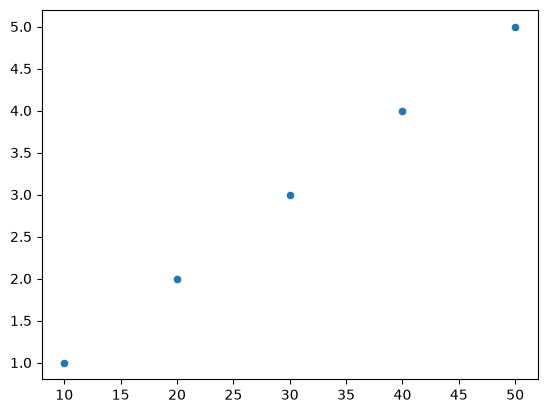

In [50]:
# Positive correlation
x_values = np.array([10, 20, 30, 40, 50])
y_values = np.array([1, 2, 3, 4, 5])

sns.scatterplot(x=x_values, y=y_values)
plt.show()


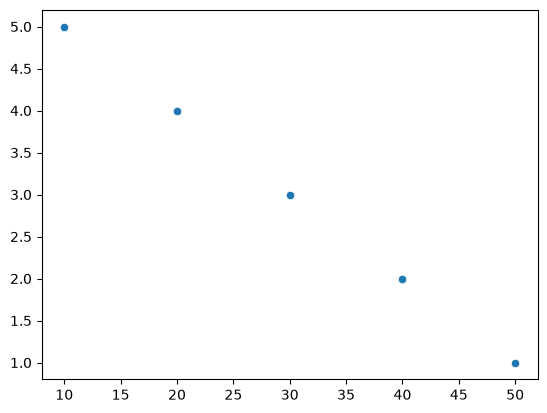

In [51]:
# Negative correlation
x_values = np.array([10, 20, 30, 40, 50])
y_values = np.array([5, 4, 3, 2, 1])

sns.scatterplot(x=x_values, y=y_values)
plt.show()


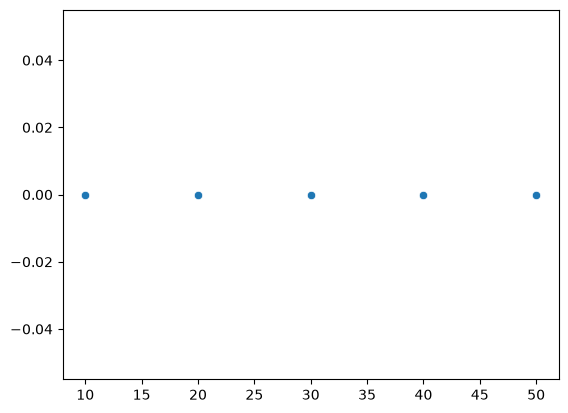

In [52]:
# No linear correlation in this example
x_values = np.array([10, 20, 30, 40, 50])
y_values = np.zeros_like(x_values)

sns.scatterplot(x=x_values, y=y_values)
plt.show()


### Pearson’s Correlation

- Ranges from **-1 to +1**:
    - **+1** indicates a perfect positive linear correlation.
    - **-1** indicates a perfect negative linear correlation.
    - **0** indicates no linear correlation.

In [53]:
positive_correlation = pd.DataFrame(
    {"x": [10, 20], "y": [10, 20]}
)
positive_correlation.corr()


,x,y
x,1.0,1.0
y,1.0,1.0


In [54]:
negative_correlation = pd.DataFrame(
    {"x": [10, 20], "y": [-10, -20]}
)
negative_correlation.corr()


,x,y
x,1.0,-1.0
y,-1.0,1.0


# Inferential Statistics

### Confidence interval

In [ ]:
sample_mean = 70
sample_std = 5
sample_size = 30
z_score = 1.96  # 95% confidence level

standard_error = sample_std / math.sqrt (sample_size)
margin_of_error = z_score * standard_error
lower_bound = sample_mean - margin_of_error
upper_bound = sample_mean + margin_of_error

print (f"Standard error: {standard_error:.3f}")
print (f"Margin of error: {margin_of_error:.3f}")
print (f"95% confidence interval: ({lower_bound:.2f}, {upper_bound:.2f})")


Standard error: 0.913
Margin of error: 1.789
95% confidence interval: (68.21, 71.79)


# Linear Algebra Fundamentals

## Vector

In [56]:
vector = np.array([10, 20, 30, 40, 50])
vector


array([10, 20, 30, 40, 50])

### Addition & Subtraction 

In [57]:
vector_1 = np.array([10, 20, 30, 40, 50])
vector_2 = np.array([5, 10, 15, 20, 25])

print("Addition:", vector_1 + vector_2)
print("Subtraction:", vector_1 - vector_2)


Addition: [15 30 45 60 75]
Subtraction: [ 5 10 15 20 25]


### Scalar Multiplication

In [58]:
scalar = 2
vector = np.array([10, 20, 30, 40, 50])

print(scalar * vector)


[ 20  40  60  80 100]


### Matrices

In [ ]:
matrix = np.array(
    [
        [1, 2, 3],
        [4, 5, 6],
        [7, 8, 9],
    ]
)
matrix


array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

## Matrix Operations

### Matrix Multiplication

In [ ]:
matrix_a = np.array([[1, 2, 3], [4, 5, 6]])
matrix_b = np.array([[7, 8], [9, 10], [11, 12]])

matrix_a @ matrix_b

array([[ 58,  64],
       [139, 154]])

### Determinant of a Matrix

In [ ]:
matrix = np.array([[3, 8], [4, 6]])
np.linalg.det(matrix)

np.float64(-14.000000000000004)

### Inverse of a Matrix

In [62]:
matrix = np.array([[4, 7], [2, 6]])
np.linalg.inv(matrix)


array([[ 0.6, -0.7],
       [-0.2,  0.4]])

### Transpose of a Matrix

The **transpose** swaps a matrix's rows and columns. In NumPy, use `.T` (or `np.transpose()`).


In [63]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])

print ("Original matrix:\n", A)
print ("\nTranspose:\n", A.T)
print ("\nShapes:", A.shape, "→", A.T.shape)

Original matrix:
 [[1 2 3]
 [4 5 6]]

Transpose:
 [[1 4]
 [2 5]
 [3 6]]

Shapes: (2, 3) → (3, 2)


## Types of Matrices

The examples below use NumPy arrays.

### Square Matrix

A square matrix has the same number of rows and columns.

In [64]:
square_matrix = np.array([[1, 2, 3],
                          [4, 5, 6],
                          [7, 8, 9]])
print (square_matrix)
print ("Is square?", square_matrix.shape[0] == square_matrix.shape[1])

[[1 2 3]
 [4 5 6]
 [7 8 9]]
Is square? True


### Diagonal Matrix

A diagonal matrix is square and has zeros everywhere except possibly on its main diagonal.

In [65]:
diagonal_matrix = np.diag([2, 4, 6])
print(diagonal_matrix)

[[2 0 0]
 [0 4 0]
 [0 0 6]]


### Identity Matrix

An identity matrix is a diagonal matrix with `1` on the main diagonal. Multiplying a compatible matrix by it leaves that matrix unchanged.

In [66]:
identity_matrix = np.eye(3, dtype=int)
print(identity_matrix)

[[1 0 0]
 [0 1 0]
 [0 0 1]]


### Zero Matrix

A zero matrix contains only zeros. Unlike diagonal and identity matrices, it does not have to be square.

In [67]:
zero_matrix = np.zeros((2, 3), dtype=int)
print(zero_matrix)

[[0 0 0]
 [0 0 0]]


### Row Matrix

A row matrix has exactly one row. Use a nested list in NumPy to preserve its two-dimensional shape.

In [68]:
row_matrix = np.array([[10, 20, 30, 40]])
print(row_matrix)
print("Shape:", row_matrix.shape)

[[10 20 30 40]]
Shape: (1, 4)


### Symmetric Matrix

A symmetric matrix is square and equal to its transpose: `A = A.T`. Its values mirror across the main diagonal.

In [69]:
symmetric_matrix = np.array([[1, 2, 3],
                             [2, 4, 5],
                             [3, 5, 6]])
print(symmetric_matrix)
print("Is symmetric?", np.array_equal(symmetric_matrix, symmetric_matrix.T))

[[1 2 3]
 [2 4 5]
 [3 5 6]]
Is symmetric? True
